## Install Dependencies

In [252]:
import json
import numpy as np
import os
from pprint import pprint
from statistics import mean, stdev
from typing import List, Dict, Callable

In [253]:
%pip install matplotlib
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 100 # TODO: Change DPI before submitting paper.


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [254]:
%pip install pandas
import pandas as pd


[notice] A new release of pip is available: 25.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Util functions

In [255]:
def load_json(path: str) -> Dict:
    with open(path, "r") as json_file:
        return json.load(json_file)

In [256]:
def printb(text: str) -> None:
    print("\033[1m" + text + "\033[0m")

In [257]:
from dataclasses import dataclass

@dataclass
class Experiment:
    qubit_num: int
    gate_count: int
    target: str

    population_size: int
    max_generations: int
    mutation_prob: float
    crossover_prob: float
    selection_strategy: str

    cache_rebuild_frequency: int
    cache_size: int
    merging_rounds: int

    source_paths: List[str]
    seeds: List[int]

    tag: str
    label: str

    data_per_seed: List[pd.DataFrame]

    fitness_scores: pd.DataFrame
    redundancies: pd.DataFrame
    simulation_durations: pd.DataFrame
    cache_utilizations: pd.DataFrame

    def __hash__(self) -> str:
        key = f"{self.qubit_num}q{self.gate_count}g{self.target}st"
        key += f"{self.population_size}p{self.max_generations}mg{self.mutation_prob}mp"
        key += f"{self.crossover_prob}cp{self.selection_strategy}s"
        key += f"{self.cache_rebuild_frequency}crf{self.cache_size}cs{self.merging_rounds}mr"
        key += f"{self.tag}t"
        return hash(key)
    
    def __eq__(self, value: "Experiment"):
        return self.__hash__() == value.__hash__()


In [258]:
# Filter experiments

def filter_experiments(experiments: List[Experiment], filter_params: Dict, sort_by: str = "qubit_num") -> List:

    filtered_experiments: List[Experiment] = []
    for experiment in experiments:

        for key, value in filter_params.items():
            
            if experiment.__dict__[key] != value:
                break 

        else:
            filtered_experiments.append(experiment)                 


    filtered_experiments.sort(key=lambda item: item.__dict__[sort_by])
    return filtered_experiments

In [259]:
def merge_fitness_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_best = total_df.groupby("generation")["fitness_#0"].mean()
    median_best = total_df.groupby("generation")["fitness_#0"].median()
    std_best = total_df.groupby("generation")["fitness_#0"].std()

    merged_df = pd.concat([avg_best, median_best, std_best], keys=[
                          "avg_best_fitness", "median_best_fitness", "std_best_fitness"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [260]:
def merge_redundancy_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_redundancy = total_df.groupby("generation")["population_redundancy"].mean()
    median_redundancy = total_df.groupby("generation")["population_redundancy"].median()
    std_redundancy = total_df.groupby("generation")["population_redundancy"].std()

    merged_df = pd.concat([avg_redundancy, median_redundancy, std_redundancy], keys=[
                          "avg_redundancy", "median_redundancy", "std_redundancy"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [261]:
def merge_simulation_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].mean()
    median_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].median()
    std_build_cache_duration = total_df.groupby(
        "generation")["build_cache_duration"].std()

    avg_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].mean()
    median_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].median()
    std_simulate_duration = total_df.groupby(
        "generation")["simulate_duration"].std()

    merged_df = pd.concat([avg_build_cache_duration, median_build_cache_duration, std_build_cache_duration, avg_simulate_duration, median_simulate_duration, std_simulate_duration], keys=[
                          "avg_build_cache_duration", "median_build_cache_duration", "std_build_cache_duration", "avg_simulate_duration", "median_simulate_duration", "std_simulate_duration"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [262]:
def merge_cache_utilization_dfs(dfs: List[pd.DataFrame]) -> pd.DataFrame:
    total_df = pd.concat(dfs)

    avg_cache_hits = total_df.groupby(
        "generation")["cache_hits"].mean()
    median_cache_hits = total_df.groupby(
        "generation")["cache_hits"].median()
    std_cache_hits = total_df.groupby(
        "generation")["cache_hits"].std()

    avg_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].mean()
    median_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].median()
    std_bigram_hit_count = total_df.groupby(
        "generation")["bigram_hit_count"].std()

    avg_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].mean()
    median_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].median()
    std_cache_hit_length = total_df.groupby(
        "generation")["average_cache_hit_length"].std()

    merged_df = pd.concat([avg_cache_hits, median_cache_hits, std_cache_hits, avg_bigram_hit_count, median_bigram_hit_count, std_bigram_hit_count, avg_cache_hit_length, median_cache_hit_length, std_cache_hit_length], keys=[
                          "avg_cache_hits", "median_cache_hits", "std_cache_hits", "avg_bigram_hit_count", "median_bigram_hit_count", "std_bigram_hit_count", "avg_cache_hit_length", "median_cache_hit_length", "std_cache_hit_length"], axis=1)
    merged_df = merged_df.reset_index()
    merged_df.fillna(0, inplace=True)

    return merged_df

In [263]:
def default_label_function(experiment: Experiment) -> str:
    return "TBD"

In [264]:
def load_experiments(results_dir: str = "results", min_generations: int = None) -> List[Experiment]:
    experiments: Dict[str, Experiment] = {}

    for file_name in os.listdir(results_dir):
        # Avoid running into issues with hyperparameter opt results.
        if not file_name.startswith("experiment_"):
            continue

        if not file_name.endswith("_config.json"):
            continue

        config_path = f"{results_dir}/{file_name}"
        config = load_json(config_path)

        path_prefix: str = config["meta"]["results_path_prefix"]
        tag_components = path_prefix.split("_")
        tag = "_".join(tag_components[1:-1])

        data_path = f"{results_dir}/{file_name.replace('_config.json', '_results.csv')}"

        experiment_data = pd.read_csv(data_path, delimiter=";")
        for column in experiment_data.columns:
            experiment_data = experiment_data.rename(columns={
                column: column.strip().replace(" ", "_")
            })

        experiment = Experiment(
            qubit_num=config["qubit_num"],
            gate_count=config["gate_count"],
            target=config["target"],

            population_size=config["ga_params"]["population_size"],
            max_generations=config["ga_params"]["max_generations"],
            mutation_prob=config["ga_params"]["mutation_prob"],
            crossover_prob=config["ga_params"]["crossover_prob"],
            selection_strategy=config["ga_params"]["selection_strategy"],

            cache_rebuild_frequency=config["caching_params"]["cache_rebuild_frequency"],
            cache_size=config["caching_params"]["cache_size"],
            merging_rounds=config["caching_params"]["merging_rounds"],

            tag=tag,
            label="TBD",

            source_paths=[
                config_path
            ],

            seeds=[
                config["meta"]["seed"]
            ],

            data_per_seed=[experiment_data],

            fitness_scores=None,
            redundancies=None,
            simulation_durations=None,
            cache_utilizations=None
        )

        if experiment in experiments:
            experiments[experiment].source_paths.append(
                experiment.source_paths[0])
            experiments[experiment].seeds.append(experiment.seeds[0])
            experiments[experiment].data_per_seed.append(
                experiment.data_per_seed[0])
        else:
            experiments[experiment] = experiment

    experiments: List[Experiment] = list(experiments.values())
    for experiment in experiments:
        data_dfs = experiment.data_per_seed
        lengths = [len(df) for df in data_dfs]

        if min_generations is None:
            min_gen_threshold = max(lengths)
        else:
            min_gen_threshold = min_generations

        entries_to_pop = [
            i for i, length in enumerate(lengths) if length < min_gen_threshold
        ]

        for entry_to_pop in reversed(entries_to_pop):
            print(
                f"Excluding fitness of {experiment.source_paths[entry_to_pop]} due to length mismatch ({lengths[entry_to_pop]} vs. {min_gen_threshold}).")

            experiment.source_paths.pop(entry_to_pop)
            experiment.seeds.pop(entry_to_pop)
            experiment.data_per_seed.pop(entry_to_pop)

        experiment.fitness_scores = merge_fitness_dfs(
            experiment.data_per_seed)
        experiment.redundancies = merge_redundancy_dfs(
            experiment.data_per_seed)
        experiment.simulation_durations = merge_simulation_dfs(
            experiment.data_per_seed)
        experiment.cache_utilizations = merge_cache_utilization_dfs(
            experiment.data_per_seed)

    return experiments

In [265]:
def set_labels(experiments: List[Experiment], labels: List[str] = None, label_function=default_label_function) -> None:
    for i, experiment in enumerate(experiments):
        if labels is not None:
            experiment.label = labels[i] 
        else:
            experiment.label = label_function(experiment) 

## Visualization Functions

In [266]:
def plot_redundancy_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.redundancies

        ax.plot(df["generation"], df["avg_redundancy"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_redundancy"] - df["std_redundancy"]
            upper_bound = df["avg_redundancy"] + df["std_redundancy"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("population redundancy")

    plt.grid()

    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')

    plt.show()
    plt.clf()

In [267]:
def plot_fitness_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False, anchor_yaxis: bool = True) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.fitness_scores

        ax.plot(df["generation"], df["avg_best_fitness"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_best_fitness"] - df["std_best_fitness"]
            upper_bound = df["avg_best_fitness"] + df["std_best_fitness"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    if anchor_yaxis:
        ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("avg. best fitness")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()

In [268]:
def plot_net_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["avg_simulate_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_simulate_duration"] - df["std_simulate_duration"]
            upper_bound = df["avg_simulate_duration"] + df["std_simulate_duration"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("net simulate time (in sec.)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf() 

In [269]:
def plot_total_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["avg_simulate_duration"] + df["avg_build_cache_duration"], label=experiment.label, linewidth=1)

        if plot_std:
            # TODO: Research if we can compute shared stdev like this.
            lower_bound = df["avg_simulate_duration"] + df["avg_build_cache_duration"] - (df["std_simulate_duration"] + df["std_build_cache_duration"])
            upper_bound = df["avg_simulate_duration"] + df["avg_build_cache_duration"] + (df["std_simulate_duration"] + df["std_build_cache_duration"])
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("total simulate time (in sec.)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [270]:
def plot_cumulative_simulation_time_per_generation(experiments: List[Experiment], target_path: str = None) -> None:
    
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.simulation_durations

        ax.plot(df["generation"], df["avg_simulate_duration"].cumsum() + df["avg_build_cache_duration"].cumsum(), label=experiment.label, linewidth=1)


    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cumulative simulate time (in sec.)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf() 

In [271]:
def print_cumulative_simulation_time(experiments: List[Experiment]) -> None:
    for experiment in experiments:
        total_time = experiment.simulation_durations["avg_simulate_duration"].sum() + experiment.simulation_durations["avg_build_cache_duration"].sum()
        print(f"Total simulation time for '{experiment.label}': {total_time}")

In [272]:
def plot_cache_hits_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["avg_cache_hits"], label=experiment.label, linewidth=1)

        if plot_std:
            # TODO: Research if we can compute shared stdev like this.
            lower_bound = df["avg_cache_hits"] - df["std_cache_hits"]
            upper_bound = df["avg_cache_hits"] + df["std_cache_hits"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cache hits")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [273]:
def plot_cumulative_cache_hits_per_generation(experiments: List[Experiment], target_path: str = None) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["avg_cache_hits"].cumsum(), label=experiment.label, linewidth=1)

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cumulative cache hits")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [274]:
def print_cumulative_cache_hits(experiments: List[Experiment]) -> None:
    for experiment in experiments:
        total_cache_hits = experiment.cache_utilizations["avg_cache_hits"].sum()
        print(f"Total cache hits for '{experiment.label}': {total_cache_hits}")

In [275]:
def plot_cache_hit_length_per_generation(experiments: List[Experiment], target_path: str = None, plot_std: bool = False) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        ax.plot(df["generation"], df["avg_cache_hit_length"], label=experiment.label, linewidth=1)

        if plot_std:
            lower_bound = df["avg_cache_hit_length"] - df["std_cache_hit_length"]
            upper_bound = df["avg_cache_hit_length"] + df["std_cache_hit_length"]
            ax.fill_between(
                df["generation"], lower_bound, upper_bound, alpha=0.2
            )

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("avg. cache hit length")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

In [276]:
def plot_bigram_share_per_generation(experiments: List[Experiment], target_path: str = None) -> None:
    ax = plt.subplot()

    for experiment in experiments:
        df = experiment.cache_utilizations

        # TODO: Research how to apply stdev in this context
        ax.plot(df["generation"], df["avg_bigram_hit_count"] / df["avg_cache_hits"] * 100, label=experiment.label, linewidth=1)

    ax.set_ylim(0)

    ax.set_xlabel("generation")

    ax.set_ylabel("cache hits that were bigrams (in %)")

    plt.grid()
    
    if len(experiments) > 1:
        plt.legend()

    if target_path is not None:
        plt.savefig(target_path, bbox_inches='tight')
    
    plt.show()
    plt.clf()  

## RQ 1: Varying Cache Parameters

In [277]:
experiments = load_experiments(
    results_dir="results/results/")

no_cache_experiment = filter_experiments(
    experiments, filter_params={"cache_size": 0, "target": "random", "selection_strategy": "roulette", "qubit_num": 6})[0]
set_labels([no_cache_experiment], labels=["no cache"])

Excluding fitness of results/results//experiment_varying_ga_setup_b8e3a09c-3ad8-4403-b955-545b4169ab8d_config.json due to length mismatch (4988 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_b8a3e2d4-72a0-4616-ada0-6837bd9d14a5_config.json due to length mismatch (4914 vs. 5000).
Excluding fitness of results/results//experiment_varying_ga_setup_7fac1499-90f2-458f-ba11-034acba78851_config.json due to length mismatch (4756 vs. 5000).
Excluding fitness of results/results//experiment_varying_merging_rounds_00582a55-3511-4f0c-b5a4-d456a4e48ad8_config.json due to length mismatch (4830 vs. 5000).
Excluding fitness of results/results//experiment_varying_merging_rounds_a2e26a42-5fa4-4030-b96d-7c18a259b25e_config.json due to length mismatch (4977 vs. 5000).
Excluding fitness of results/results//experiment_varying_merging_rounds_5b5c9a0f-f126-4b41-9ae9-6ad1cd164f31_config.json due to length mismatch (3874 vs. 5000).
Excluding fitness of results/results//experiment_var

Best fitness per generation:


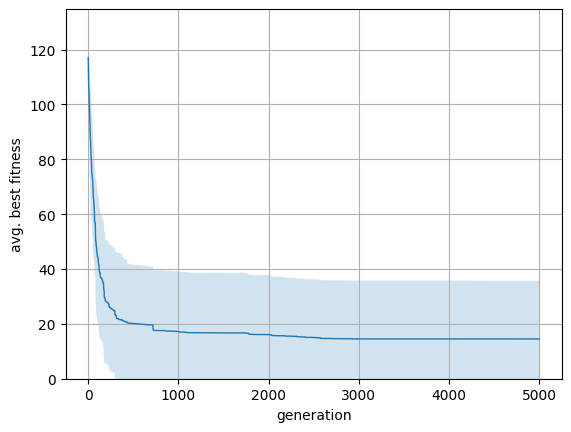

<Figure size 640x480 with 0 Axes>

In [278]:
printb("Best fitness per generation:")
plot_fitness_per_generation([no_cache_experiment], plot_std=True, target_path="results/avg_fitness.png")

Population redundancy per generation:


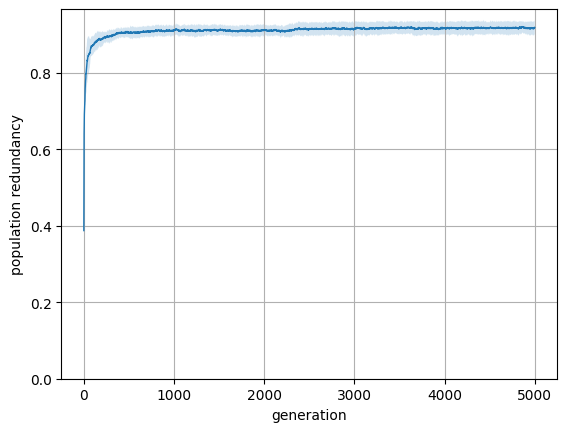

<Figure size 640x480 with 0 Axes>

In [279]:
printb("Population redundancy per generation:")
plot_redundancy_per_generation([no_cache_experiment], plot_std=True, target_path="results/redundancy.png")

### RQ 1.1: Varying Rebuild Frequency

In [280]:
def rebuild_frequency_label(experiment: Experiment) -> str:
    return f"every {experiment.cache_rebuild_frequency} generations"

In [281]:
varying_rebuild_frequency_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "target": "random",
    "tag": "varying_rebuild_frequency"
}, sort_by="cache_rebuild_frequency")
set_labels(varying_rebuild_frequency_experiments, label_function=rebuild_frequency_label)
print(
    f"Number of rebuild frequency experiments: {len(varying_rebuild_frequency_experiments)}")
print(
    f"Seed counts per config: {[len(experiment.seeds) for experiment in varying_rebuild_frequency_experiments]}")



Number of rebuild frequency experiments: 4
Seed counts per config: [8, 10, 10, 10]


Net simulation time per generation:


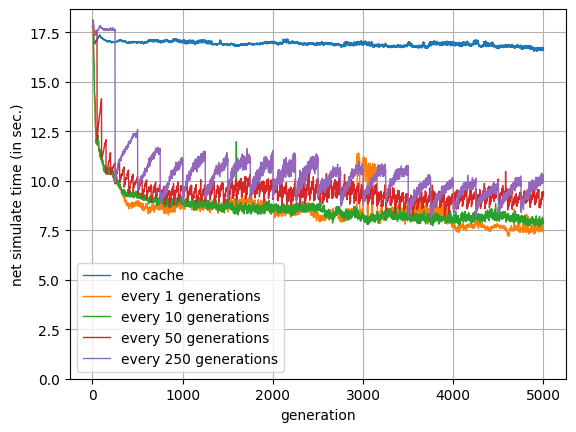

Total simulation time per generation:


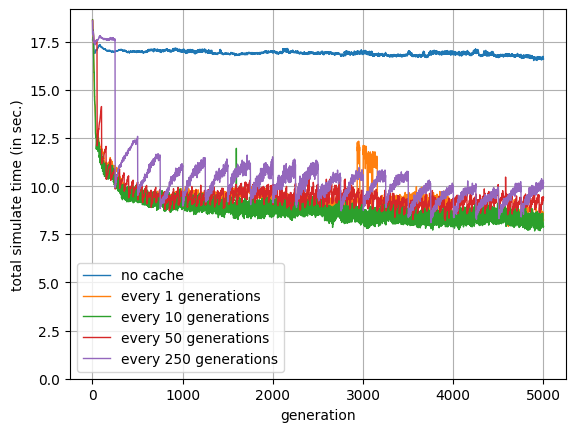

cumulative simulation time:


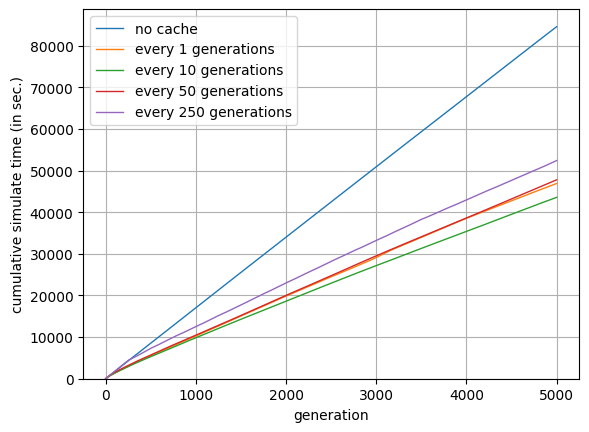

Total simulation time for 'no cache': 84580.4637387
Total simulation time for 'every 1 generations': 46911.19987425
Total simulation time for 'every 10 generations': 43574.978754100004
Total simulation time for 'every 50 generations': 47789.97939
Total simulation time for 'every 250 generations': 52416.9504483


<Figure size 640x480 with 0 Axes>

In [282]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation([no_cache_experiment] + varying_rebuild_frequency_experiments, plot_std=False, target_path="results/net_time_different_rf.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation([no_cache_experiment] + varying_rebuild_frequency_experiments, plot_std=False, target_path="results/total_time_different_rf.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation([no_cache_experiment] + varying_rebuild_frequency_experiments, target_path="results/cum_time_different_rf.png")
print_cumulative_simulation_time([no_cache_experiment] + varying_rebuild_frequency_experiments)

Cache hits per generation:


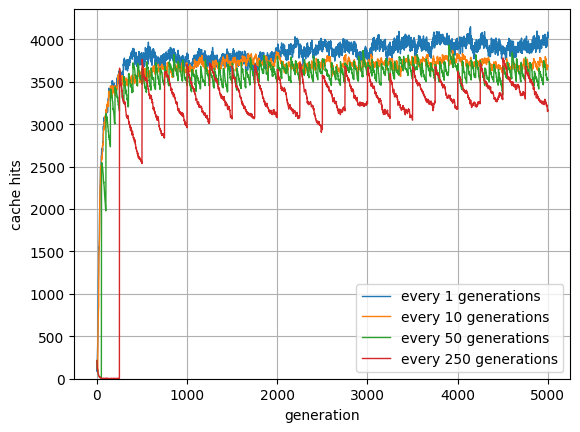

cumulative cache hits:


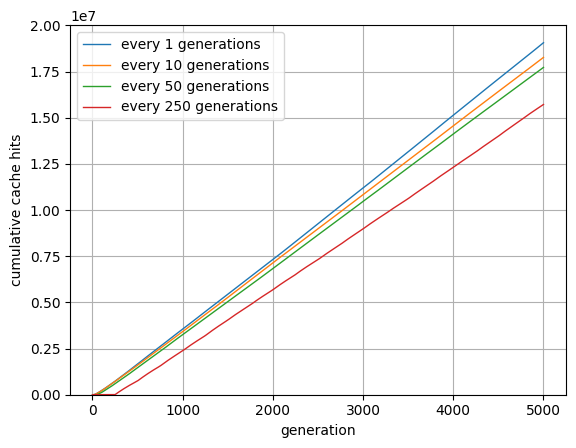

Total cache hits for 'every 1 generations': 19062599.0
Total cache hits for 'every 10 generations': 18268238.1
Total cache hits for 'every 50 generations': 17725565.5
Total cache hits for 'every 250 generations': 15717675.3


<Figure size 640x480 with 0 Axes>

In [283]:
printb("Cache hits per generation:")
plot_cache_hits_per_generation(varying_rebuild_frequency_experiments, plot_std=False, target_path="results/hits_different_rf.png")

printb("cumulative cache hits:")
plot_cumulative_cache_hits_per_generation(varying_rebuild_frequency_experiments, target_path="results/cum_hits_different_rf.png")
print_cumulative_cache_hits(varying_rebuild_frequency_experiments)

Average cache hit length:


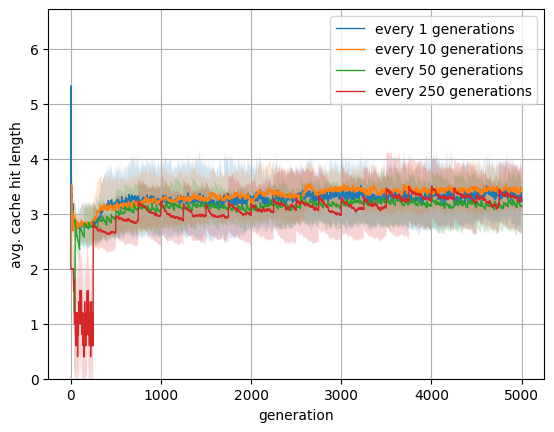

Share of bigrams:


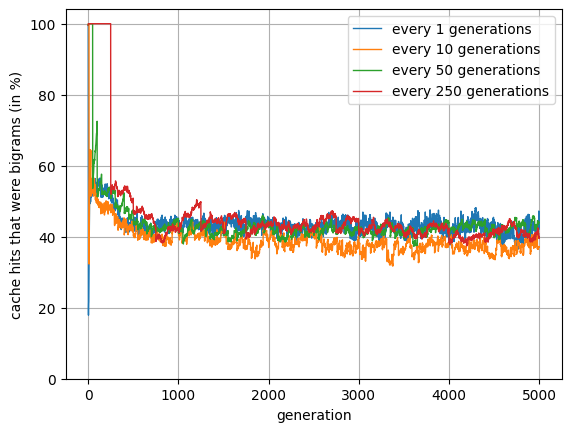

<Figure size 640x480 with 0 Axes>

In [284]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_rebuild_frequency_experiments, plot_std=True, target_path="results/hit_length_different_rf.png")

printb("Share of bigrams:")
plot_bigram_share_per_generation(varying_rebuild_frequency_experiments, target_path="results/bigram_share_different_rf.png")

### RQ 1.2: Varying Merging Rounds

In [285]:
def rebuild_mr_label(experiment: Experiment) -> str:
    return f"{experiment.merging_rounds} merging rounds"

In [286]:
varying_merging_rounds_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "target": "random",
    "tag": "varying_merging_rounds"
}, sort_by="merging_rounds")
set_labels(varying_merging_rounds_experiments, label_function=rebuild_mr_label)
print(
    f"Number of merging round experiments: {len(varying_merging_rounds_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in varying_merging_rounds_experiments])}")



Number of merging round experiments: 4
Seed counts per config: {8, 6, 7}


Net simulation time per generation:


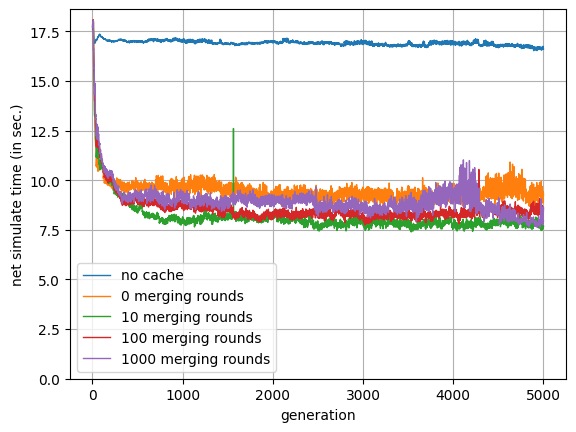

Total simulation time per generation:


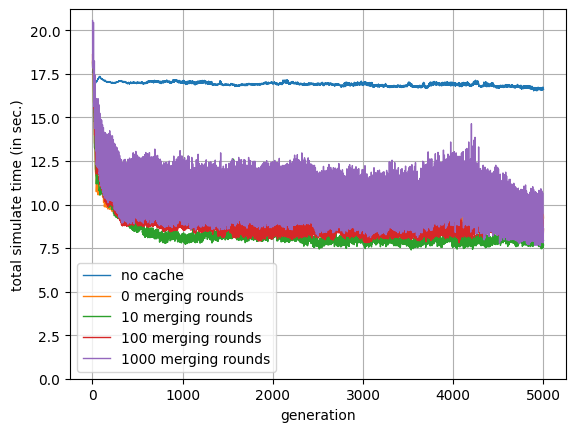

cumulative simulation time:


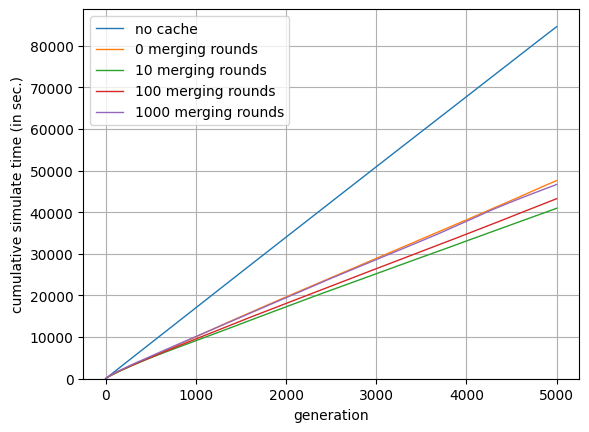

Total simulation time for 'no cache': 84580.4637387
Total simulation time for '0 merging rounds': 47609.82347233333
Total simulation time for '10 merging rounds': 40950.39329449999
Total simulation time for '100 merging rounds': 43253.987495999994
Total simulation time for '1000 merging rounds': 46667.608141000004


<Figure size 640x480 with 0 Axes>

In [287]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation([no_cache_experiment] + varying_merging_rounds_experiments, plot_std=False, target_path="results/net_time_different_mr.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation([no_cache_experiment] + varying_merging_rounds_experiments, plot_std=False, target_path="results/total_time_different_mr.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation([no_cache_experiment] + varying_merging_rounds_experiments, target_path="results/cum_time_different_mr.png") 
print_cumulative_simulation_time([no_cache_experiment] + varying_merging_rounds_experiments)

Average cache hit length:


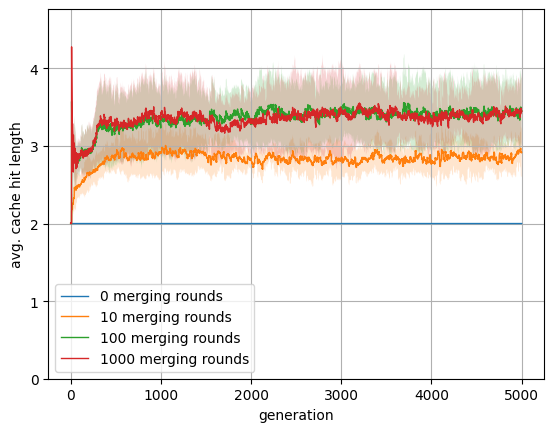

Share of bigrams:


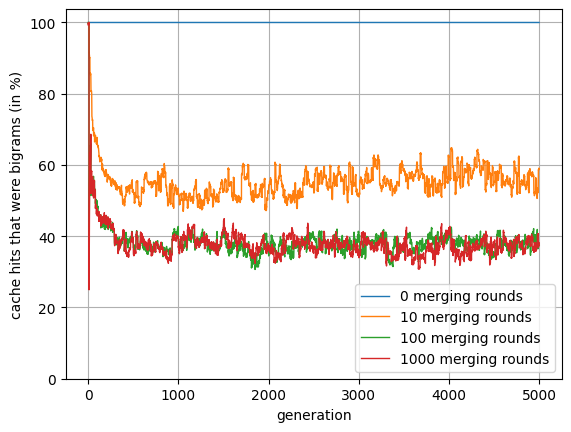

<Figure size 640x480 with 0 Axes>

In [288]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_merging_rounds_experiments, plot_std=True, target_path="results/hit_length_different_mr.png")

printb("Share of bigrams:")
plot_bigram_share_per_generation(varying_merging_rounds_experiments, target_path="results/bigram_share_different_mr.png")

## RQ 1.3 Varying Cache Size

In [289]:
def rebuild_cs_label(experiment: Experiment) -> str:
    return f"cache size = {experiment.cache_size}"

In [290]:
varying_cache_size_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "target": "random",
    "selection_strategy": "roulette"
}, sort_by="cache_size")

set_labels(varying_cache_size_experiments, label_function=rebuild_cs_label)
print(
    f"Number of cache size experiments: {len(varying_cache_size_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in varying_cache_size_experiments])}")



Number of cache size experiments: 2
Seed counts per config: {8, 4}


Net simulation time per generation:


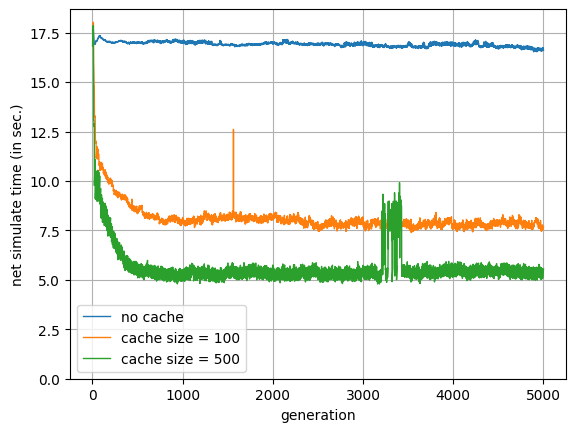

Total simulation time per generation:


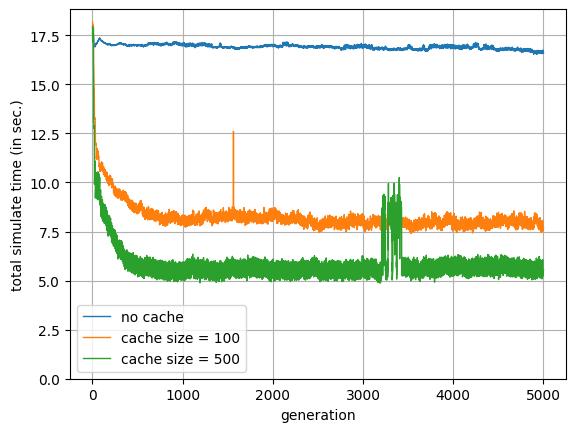

cumulative simulation time:


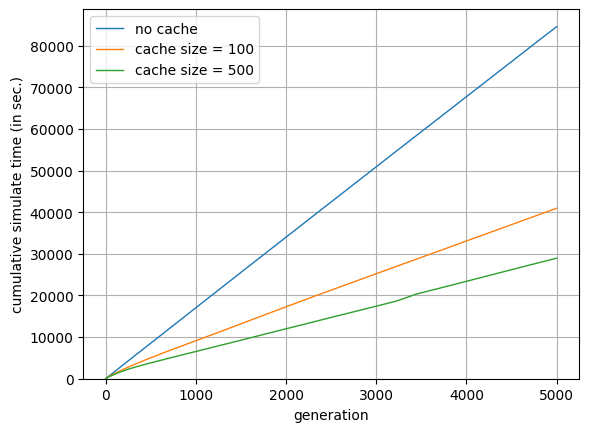

Total simulation time for 'no cache': 84580.4637387
Total simulation time for 'cache size = 100': 40950.39329449999
Total simulation time for 'cache size = 500': 28956.897689500005


<Figure size 640x480 with 0 Axes>

In [291]:
printb("Net simulation time per generation:")
plot_net_simulation_time_per_generation([no_cache_experiment] + varying_cache_size_experiments, plot_std=False, target_path="results/net_time_different_cs.png")

printb("Total simulation time per generation:")
plot_total_simulation_time_per_generation([no_cache_experiment] + varying_cache_size_experiments, plot_std=False, target_path="results/total_time_different_cs.png")

printb("cumulative simulation time:")
plot_cumulative_simulation_time_per_generation([no_cache_experiment] + varying_cache_size_experiments, target_path="results/cum_time_different_cs.png") 
print_cumulative_simulation_time([no_cache_experiment] + varying_cache_size_experiments)

Cache hits per generation:


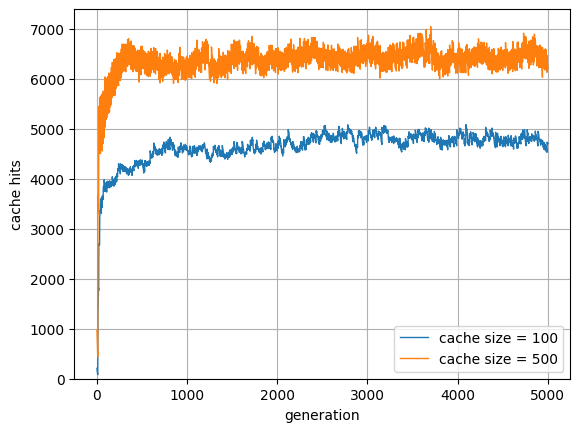

cumulative cache hits:


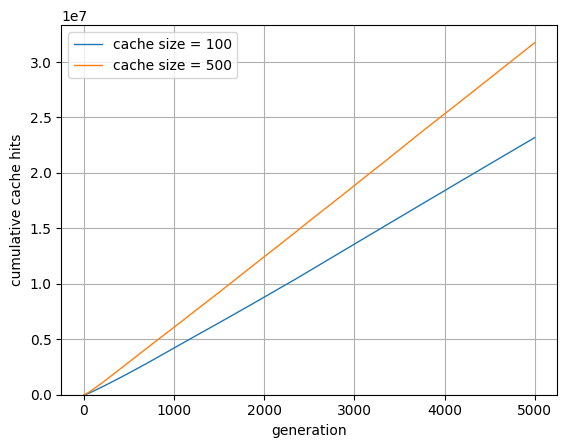

Total cache hits for 'cache size = 100': 23179364.25
Total cache hits for 'cache size = 500': 31736494.5


<Figure size 640x480 with 0 Axes>

In [292]:
printb("Cache hits per generation:")
plot_cache_hits_per_generation(varying_cache_size_experiments, plot_std=False, target_path="results/hits_different_cs.png")

printb("cumulative cache hits:")
plot_cumulative_cache_hits_per_generation(varying_cache_size_experiments, target_path="results/cum_hits_different_cs.png")
print_cumulative_cache_hits(varying_cache_size_experiments)

Average cache hit length:


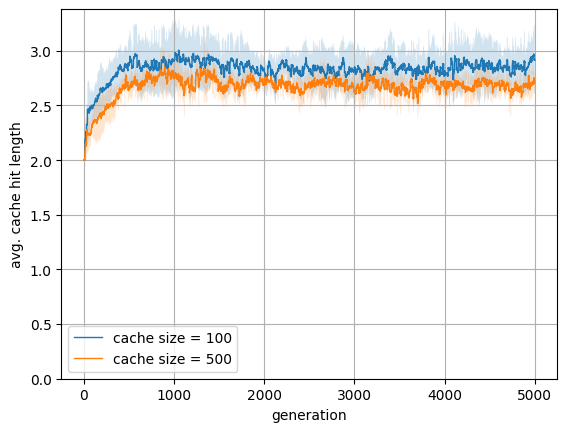

Share of bigrams:


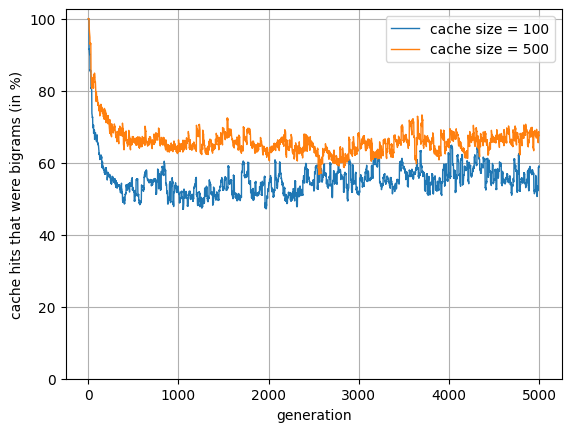

<Figure size 640x480 with 0 Axes>

In [293]:
printb("Average cache hit length:")
plot_cache_hit_length_per_generation(varying_cache_size_experiments, plot_std=True, target_path="results/hit_length_different_cs.png")

printb("Share of bigrams:")
plot_bigram_share_per_generation(varying_cache_size_experiments, target_path="results/bigram_share_different_cs.png")

### RQ2.2: Results for different qubit counts

In [294]:
def rebuild_qubit_count_label(experiment: Experiment) -> str:
    if experiment.cache_size == 0:
        return "no cache"
    else:
        return "using cache"

In [295]:
six_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
}) + filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 0,
    "target": "random",
})

set_labels(six_qubit_experiments, label_function=rebuild_qubit_count_label)
print(
    f"Number of 6 qubit experiments: {len(six_qubit_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in six_qubit_experiments])}")



Number of 6 qubit experiments: 2
Seed counts per config: {8, 5}


In [296]:
five_qubit_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 5,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
}) + filter_experiments(experiments, filter_params={
    "qubit_num": 5,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 0,
    "target": "random",
})

set_labels(five_qubit_experiments, label_function=rebuild_qubit_count_label)
print(
    f"Number of 5 qubit experiments: {len(five_qubit_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in five_qubit_experiments])}")



Number of 5 qubit experiments: 2
Seed counts per config: {5}


### RQ2.3: Different GA Setups on Random Target

In [297]:
def rebuild_ga_setup_label(experiment: Experiment) -> str:
    return f"target = {experiment.target}, selection = {experiment.selection_strategy}"

In [298]:
random_unitary_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "random",
}, sort_by="selection_strategy")

set_labels(random_unitary_experiments, label_function=rebuild_ga_setup_label)
print(
    f"Number of random unitary experiments: {len(random_unitary_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in random_unitary_experiments])}")



Number of random unitary experiments: 2
Seed counts per config: {8, 5}


Fitness for random unitary experiments


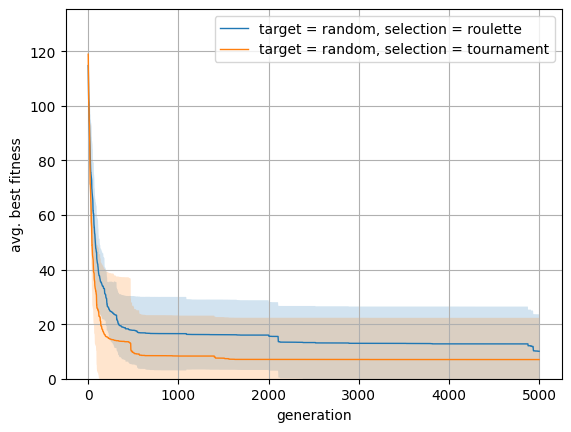

Redundancy of random unitary experiments


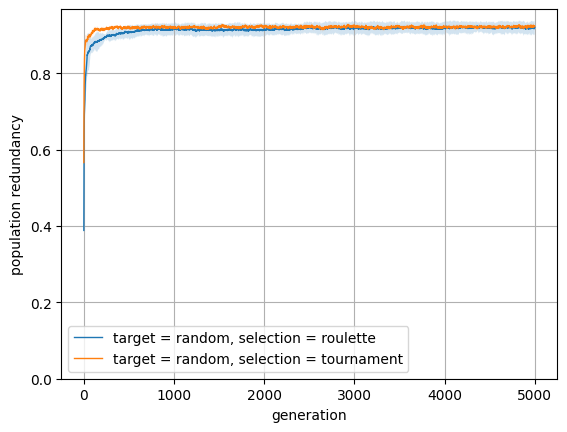

<Figure size 640x480 with 0 Axes>

In [299]:
# fitness scores and redundancies for different selection strategies
# on random target

printb("Fitness for random unitary experiments")
plot_fitness_per_generation(random_unitary_experiments, plot_std=True, target_path="results/fitness_random_unitaries.png")

printb("Redundancy of random unitary experiments")
plot_redundancy_per_generation(random_unitary_experiments, plot_std=True, target_path="results/redundancy_random_unitaries.png")


Simulation time of random unitary experiments


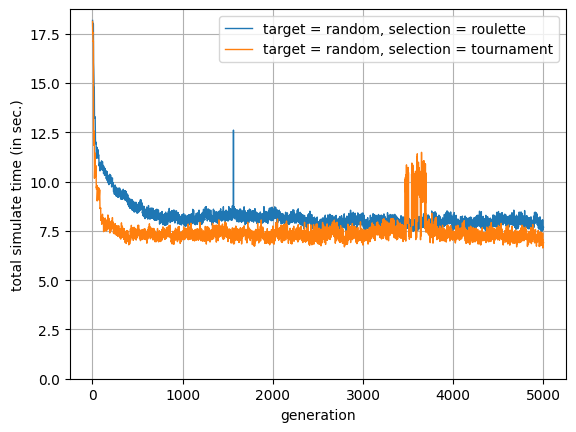

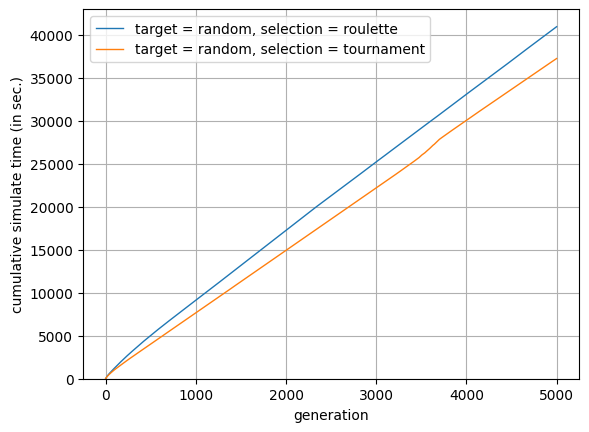

Total simulation time for 'target = random, selection = roulette': 40950.39329449999
Total simulation time for 'target = random, selection = tournament': 37248.2197472


<Figure size 640x480 with 0 Axes>

In [300]:
# total simulation of both selection strategies on random target

printb("Simulation time of random unitary experiments")
plot_total_simulation_time_per_generation(random_unitary_experiments, target_path="results/total_time_random_unitaries.png")
plot_cumulative_simulation_time_per_generation(random_unitary_experiments, target_path="results/cum_time_random_unitaries.png")
print_cumulative_simulation_time(random_unitary_experiments)

Cache hits for random unitary experiments


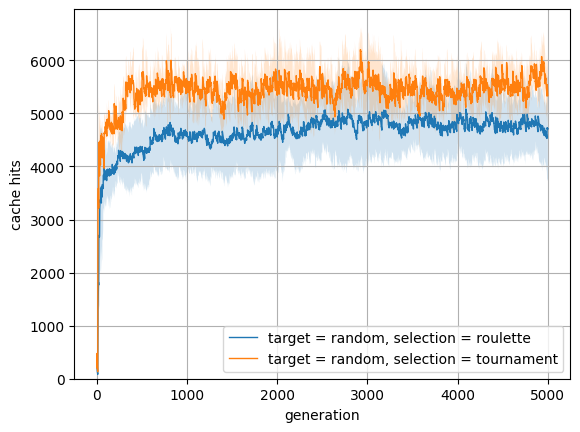

Cache hit length for random unitary experiments


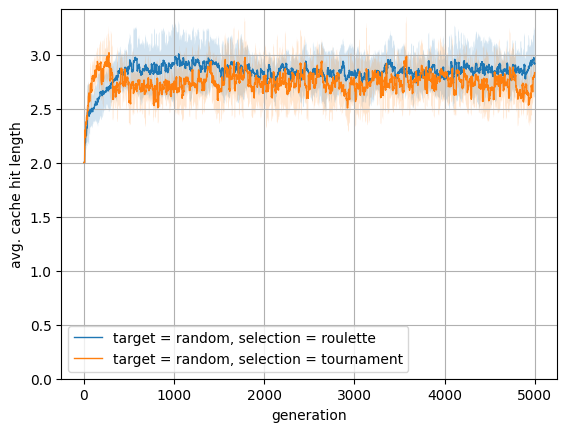

<Figure size 640x480 with 0 Axes>

In [301]:
printb("Cache hits for random unitary experiments")
plot_cache_hits_per_generation(random_unitary_experiments, plot_std=True, target_path="results/hits_random_unitaries.png")

printb("Cache hit length for random unitary experiments")
plot_cache_hit_length_per_generation(random_unitary_experiments, plot_std=True, target_path="results/hit_length_random_unitaries.png")

### RQ2.3: Different GA Setups on QFT Target

In [302]:
qft_experiments = filter_experiments(experiments, filter_params={
    "qubit_num": 6,
    "gate_count": 20,
    "merging_rounds": 10,
    "cache_rebuild_frequency": 10,
    "cache_size": 100,
    "target": "qft",
}, sort_by="selection_strategy")

set_labels(qft_experiments, label_function=rebuild_ga_setup_label)
print(
    f"Number of qft unitary experiments: {len(qft_experiments)}")
print(
    f"Seed counts per config: {set([len(experiment.seeds) for experiment in qft_experiments])}")



Number of qft unitary experiments: 2
Seed counts per config: {3, 4}


Fitness for QFT experiments


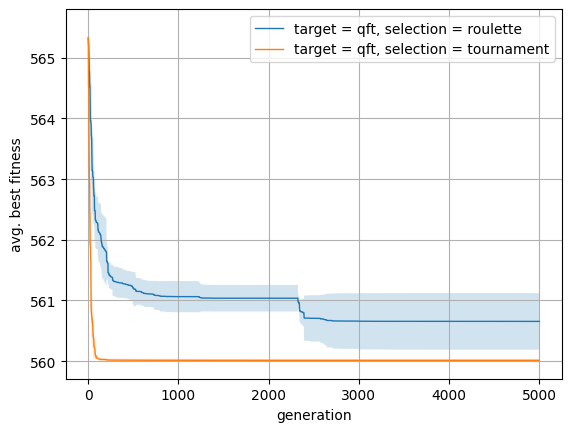

Redundancy of QFT experiments


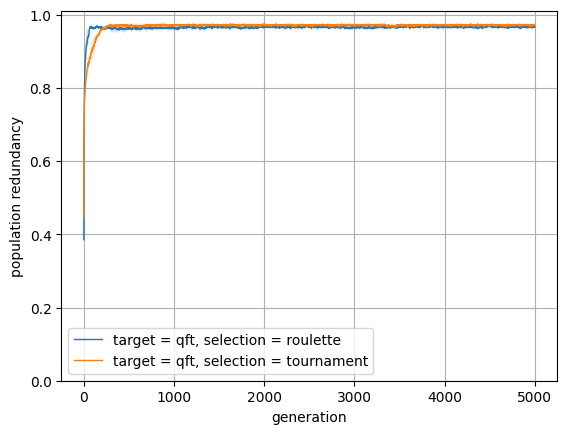

<Figure size 640x480 with 0 Axes>

In [303]:
# fitness scores and redundancies for different selection strategies
# on qft target

printb("Fitness for QFT experiments")
plot_fitness_per_generation(qft_experiments, plot_std=True, anchor_yaxis=False, target_path="results/fitness_qft.png")
printb("Redundancy of QFT experiments")
plot_redundancy_per_generation(qft_experiments, plot_std=True, target_path="results/redundancy_qft.png")

Simulation time of QFT experiments


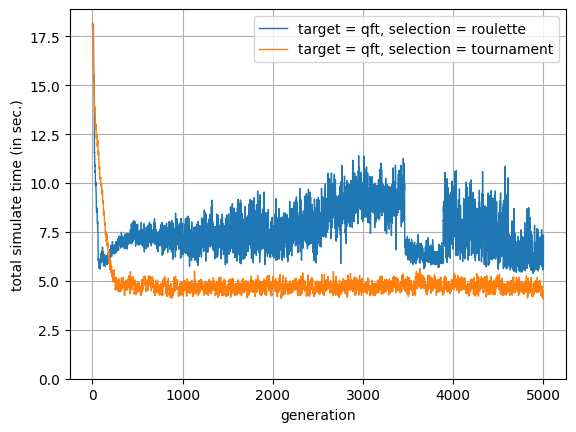

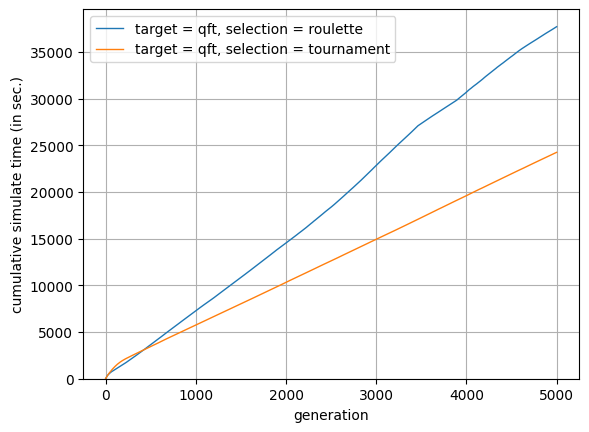

Total simulation time for 'target = qft, selection = roulette': 37690.24942266666
Total simulation time for 'target = qft, selection = tournament': 24235.955611


<Figure size 640x480 with 0 Axes>

In [304]:
# total simulation of both selection strategies on qft target
printb("Simulation time of QFT experiments")
plot_total_simulation_time_per_generation(qft_experiments, target_path="results/total_time_qft.png")
plot_cumulative_simulation_time_per_generation(qft_experiments, target_path="results/cum_time_qft.png")
print_cumulative_simulation_time(qft_experiments)

Cache hits for qft experiments


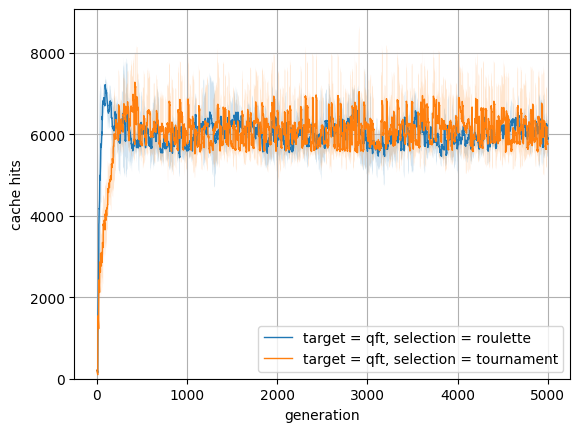

Cache hit length for qft experiments


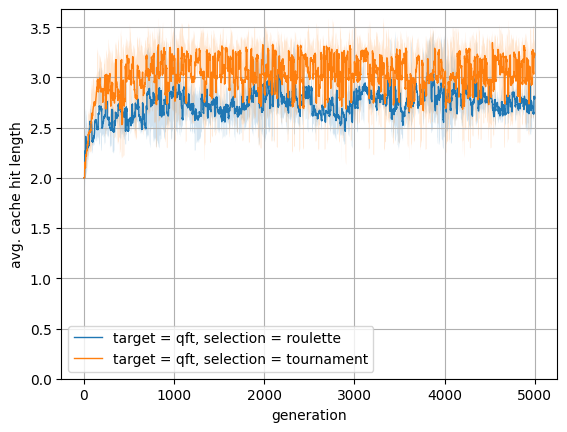

<Figure size 640x480 with 0 Axes>

In [305]:
printb("Cache hits for qft experiments")
plot_cache_hits_per_generation(qft_experiments, plot_std=True, target_path="results/hits_qft.png")

printb("Cache hit length for qft experiments")
plot_cache_hit_length_per_generation(qft_experiments, plot_std=True, target_path="results/hit_length_qft.png")
